# 📓 Cas d'usage IA — Marketing bancaire

**Auteur·e** : Jérémy Calvo
**Promo** : Dev-id — Parcours 2 (Pros IT)
**Date début** : 29/09/2026
**Dernière mise à jour** : 02/10/2026


## 0. Imports & configuration

In [1]:
# Imports standards
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Accès au package src/ (la logique métier y vit, pas dans le notebook)
REPO_ROOT = Path.cwd()
if (REPO_ROOT / "notebooks").exists():
    REPO_ROOT = REPO_ROOT
elif (REPO_ROOT.parent / "data").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.config import DATA_PATH, RANDOM_STATE
from src.data import load_dataset, clean_dataset, build_features, get_X_y, load_prepared
from src.preprocessing import make_preprocessor, build_scenarios

# Affichage
pd.set_option("display.max_columns", 100)


## 0.5 Traçabilité de la session

In [2]:
import hashlib
import platform
import subprocess

import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn

from src.config import DATA_PATH


def sha256(path) -> str:
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def git_commit() -> str:
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "--short", "HEAD"], text=True
        ).strip()
    except Exception:
        return "n/a"


DATASET_VERSION = {
    "name": "UCI Bank Marketing — bank-additional-full.csv",
    "source": "https://archive.ics.uci.edu/dataset/222/bank+marketing",
    "extracted_at": "JJ/MM/AAAA",  # à compléter (date d'extraction du CSV)
    "sha256": sha256(DATA_PATH),
    "n_rows": 41188,
    "n_cols": 21,
    "separator": ";",
}

ENV_VERSIONS = {
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": seaborn.__version__,
}

print("Dataset :", DATASET_VERSION)
print("Environnement :", ENV_VERSIONS)
print("Commit Git :", git_commit())


Dataset : {'name': 'UCI Bank Marketing — bank-additional-full.csv', 'source': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'extracted_at': 'JJ/MM/AAAA', 'sha256': '74adfc578bf77a7ff4bb1ba4a9f8709d9e3c6907342959c2c8416847e0afb4d8', 'n_rows': 41188, 'n_cols': 21, 'separator': ';'}
Environnement : {'python': '3.11.15', 'pandas': '2.3.3', 'numpy': '2.4.6', 'scikit-learn': '1.5.1', 'matplotlib': '3.11.2', 'seaborn': '0.13.2'}
Commit Git : 371ccb3


---
## 1. Cadrage métier & problème

### 1.1 Contexte client

Le client est une **banque de détail** qui propose à ses clients des produits d'épargne, notamment des **dépôts à terme**. Pour les commercialiser, elle mène des **campagnes de démarchage téléphonique** : des conseillers appellent des clients pour leur proposer le produit.

Ces campagnes ont un **coût élevé** (temps des conseillers, plateformes d'appels). Mal ciblées, elles **saturent les clients d'appels non pertinents** et **dégradent la relation commerciale**. Le client veut donc **concentrer l'effort sur les bons profils**, **réduire les appels inutiles** et **améliorer l'expérience client**.

Le recours à l'IA est motivé par la volonté d'**estimer en amont la probabilité de souscription** à partir du profil et de l'historique des contacts. L'enjeu n'est pas seulement technique : démarcher sur la base de données personnelles (âge, profession, situation familiale, niveau d'éducation) soulève des **questions d'équité, de conformité RGPD et de pratiques commerciales acceptables**.


### 1.2 Énoncé du problème IA

**Tâche** : classification binaire supervisée.

- **Entrées (X)** : caractéristiques du client et de l'historique des contacts, **disponibles avant l'issue de la campagne**.
- **Cible (y)** : `y ∈ {oui, non}` — le client a-t-il souscrit un dépôt à terme ?
- **Sortie opérationnelle** : une **probabilité de souscription** (score entre 0 et 1), utilisée pour **prioriser** les clients à appeler — **pas** une décision automatique de démarchage.


### 1.3 Bénéficiaires & impacts

| Type | Acteur | Bénéfice / impact |
|---|---|---|
| Direct | Conseillers | Appels mieux ciblés, moins de temps perdu. |
| Direct | Responsable de campagne | Meilleure allocation de l'effort, pilotage par la probabilité. |
| Indirect | Clients | Moins d'appels non pertinents (meilleure expérience) ; **risque d'être écarté du démarchage** par le modèle. |
| Indirect | Banque | Meilleur taux de conversion, **risque réputationnel/juridique** si ciblage discriminant ou non conforme. |

> **Point de vigilance** : un modèle qui prédit mal pour un sous-groupe peut **priver ce groupe d'une opportunité commerciale** (moins sollicité) ou le **sur-solliciter**.


### 1.4 Critères de succès

| Type | Critère | Cible initiale (client) | Justification |
|---|---|---|---|
| Métier | Taux de conversion des clients contactés | Améliorer vs ciblage aléatoire | Concentrer l'effort sur les profils les plus réceptifs. |
| Modèle | Rappel sur la classe « oui » (classe minoritaire) | Priorité au rappel | Rater un souscripteur = un appel potentiel manqué. |
| Modèle | F1-score classe « oui » | ≥ 0.50 (ordre de grandeur) | Équilibre rappel / précision sur la classe positive. |
| Modèle | ROC-AUC | ≥ 0.75 (ordre de grandeur) | Capacité d'ordonnancement, indépendante du seuil. |
| Opérationnel | Latence de réponse API | < 500 ms | Interrogation avant appel par un conseiller. |
| Opérationnel | Disponibilité du service | > 99 % | Usage courant en agence. |


### 1.5 Risques éthiques & réglementaires anticipés

**Données personnelles (RGPD)**
- Le jeu contient des **données personnelles** : socio-démographiques (`age`, `job`, `marital`, `education`), situation bancaire (`default`, `housing`, `loan`) et historique de contact.
- **Article 9 (catégories particulières)** : a priori **aucune** donnée de santé / religion / origine / orientation sexuelle **au sens strict**. Mais `marital`, `job` et `education` peuvent **révéler indirectement** des situations sensibles et servent un **ciblage commercial** → sensibilité **éthique** à documenter.
- **Base légale** : à **confirmer avec le DPO** (piste prudente : intérêt légitime et/ou consentement), **non présumée acquise**.
- **Obligations** : information des personnes, **minimisation**, **durée de conservation** limitée.

**Biais & équité**
- Risque de **discrimination indirecte** via un ciblage fondé sur l'âge, la profession, la situation familiale, l'éducation.

**Fuite d'information (leakage)**
- `duration` (durée du dernier appel) n'est connue qu'**une fois l'appel terminé** : l'utiliser pour décider *qui appeler en amont* constitue une **fuite d'information**.


### 1.6 📝 Synthèse cadrage

- **Problème** : estimer la probabilité qu'un client souscrive à un dépôt à terme, pour cibler les campagnes de démarchage téléphonique.
- **Tâche IA** : classification binaire supervisée (cible `y`), sortie = **probabilité** (aide à la priorisation), pas une décision automatique.
- **Critère de succès dominant** : performance sur la **classe minoritaire « oui »** (rappel / F1 / ROC-AUC), en tenant compte du coût d'un appel inutile.
- **Principal risque** : discrimination indirecte via des variables sensibles + conformité RGPD à cadrer avec le DPO.


---
## 2. Identification & acquisition des données

### 2.1 Sources

Le jeu de données provient du **UCI Machine Learning Repository** (Bank Marketing). Il est issu d'une campagne de démarchage téléphonique d'une **banque portugaise** et est fourni sous forme d'un fichier CSV au séparateur point-virgule.

| Source | Type | Volumétrie | Format | Accès | Date extraction |
|---|---|---|---|---|---|
| UCI ML Repository — Bank Marketing | Jeu de données public | 41 188 lignes × 21 colonnes | CSV (`;`) | Lecture seule (fichier local) | `JJ/MM/AAAA` |


In [3]:
df = pd.read_csv(DATA_PATH, sep=";")

print("Dimensions :", df.shape)
print("\nColonnes :", df.columns.tolist())
print("\nTypes :")
print(df.dtypes)

df.head(3)


Dimensions : (41188, 21)

Colonnes : ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Types :
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### 2.3 Dictionnaire de variables

Trois colonnes de qualification sont distinguées : **donnée personnelle** (au sens du RGPD), **catégorie particulière** (article 9) et **variable sensible pour le ciblage commercial** (critère de discrimination possible ou jugement éthique).

| Variable | Description | Type | Plage / valeurs | Cible ? | Donnée perso ? | Art. 9 ? | Sensible ciblage ? |
|---|---|---|---|---|---|---|---|
| `age` | Âge du client | num | 17 – 98 | non | oui | non | oui |
| `job` | Type d'emploi | cat | admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown | non | oui | non | oui |
| `marital` | Statut marital | cat | married, single, divorced, unknown | non | oui | non | oui |
| `education` | Niveau d'éducation | cat | basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown | non | oui | non | oui |
| `default` | Crédit en défaut de paiement | cat | yes, no, unknown | non | oui | non | non |
| `housing` | Prêt immobilier | cat | yes, no, unknown | non | oui | non | non |
| `loan` | Prêt personnel | cat | yes, no, unknown | non | oui | non | non |
| `contact` | Moyen de contact | cat | cellular, telephone | non | oui | non | non |
| `month` | Mois du dernier contact | cat | jan … dec | non | oui | non | non |
| `day_of_week` | Jour de la semaine du dernier contact | cat | mon … fri | non | oui | non | non |
| `duration` | Durée du dernier contact (secondes) | num | 0 – 4 918 | non | oui | non | non |
| `campaign` | Nombre de contacts durant cette campagne | num | 1 – 56 | non | oui | non | non |
| `pdays` | Jours depuis le dernier contact d'une campagne précédente | num | 0 – 999 (999 = jamais recontacté) | non | oui | non | non |
| `previous` | Nombre de contacts avant cette campagne | num | 0 – 7 | non | oui | non | non |
| `poutcome` | Résultat de la campagne précédente | cat | failure, nonexistent, success | non | oui | non | non |
| `emp.var.rate` | Taux de variation de l'emploi | num | -3,4 – 1,4 | non | non | non | non |
| `cons.price.idx` | Indice des prix à la consommation | num | 92,2 – 94,8 | non | non | non | non |
| `cons.conf.idx` | Indice de confiance des consommateurs | num | -50,8 – -26,9 | non | non | non | non |
| `euribor3m` | Taux Euribor 3 mois | num | 0,63 – 5,05 | non | non | non | non |
| `nr.employed` | Nombre de salariés | num | 4 963,6 – 5 228,1 | non | non | non | non |
| `y` | Le client a-t-il souscrit un dépôt à terme ? | cat | yes, no | **oui** | oui | non | — |

> Aucune variable ne relève d'une **catégorie particulière** au sens de l'article 9 du RGPD. En revanche, `age`, `job`, `marital` et `education` sont des **critères de discrimination** possibles et doivent être surveillés dans un usage de ciblage commercial.

### 2.4 📝 Synthèse acquisition

- **Origine** : jeu public UCI Bank Marketing, campagne d'une banque portugaise ; aucune valeur manquante au sens strict (pas de `NaN`).
- **Volumétrie** : 41 188 observations, 20 variables explicatives et une cible binaire `y`.
- **Qualité apparente** : 12 lignes dupliquées ; des modalités `unknown` sur `job`, `marital`, `education`, `default`, `housing`, `loan` ; la valeur `999` de `pdays` est une sentinelle (« jamais recontacté »).
- **Données personnelles** : toutes les variables décrivant le client ou ses contacts ; les cinq indicateurs macro-économiques ne le sont pas.
- **Variables sensibles pour le ciblage** : `age`, `job`, `marital`, `education`.


---
## 3. Exploration & analyse des données (EDA)

Objectif : comprendre la donnée avant de la transformer — qualité, distributions, déséquilibre de la cible et écarts entre groupes.


In [4]:
# 3.1 Premier coup d'œil
print("Dimensions :", df.shape)
df.info()

df.head()


Dimensions : (41188, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.c

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
# Statistiques descriptives (numériques + catégorielles)
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,41188.0,NaN,NaN,NaN,40.02406,10.42125,17.0,32.0,38.0,47.0,98.0
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# 3.2 Qualité des données

# Valeurs manquantes au sens strict
print("Valeurs manquantes :", int(df.isna().sum().sum()))

# Doublons exacts
print("Lignes dupliquées :", int(df.duplicated().sum()))

# Modalités "unknown" (valeurs présentes, non manquantes)
print("\nModalités 'unknown' par variable :")
for col in df.select_dtypes(include="object").columns:
    n = int((df[col] == "unknown").sum())
    if n:
        print(f"  {col} : {n}")

# Sentinelle pdays = 999 ("jamais recontacté")
print("\npdays = 999 :", int((df["pdays"] == 999).sum()), "lignes")


Valeurs manquantes : 0
Lignes dupliquées : 12

Modalités 'unknown' par variable :
  job : 330
  marital : 80
  education : 1731
  default : 8597
  housing : 990
  loan : 990

pdays = 999 : 39673 lignes


**Doublons.** Le fichier ne contient **aucun identifiant client**. Les 12 lignes dupliquées sont **identiques sur les 21 colonnes**, mais on ne peut pas déterminer s'il s'agit d'un même client enregistré deux fois ou de deux clients distincts partageant exactement le même profil et le même contact. Constat à ce stade : **12 lignes strictement identiques**, sans clé permettant de trancher. Le traitement sera décidé plus tard.


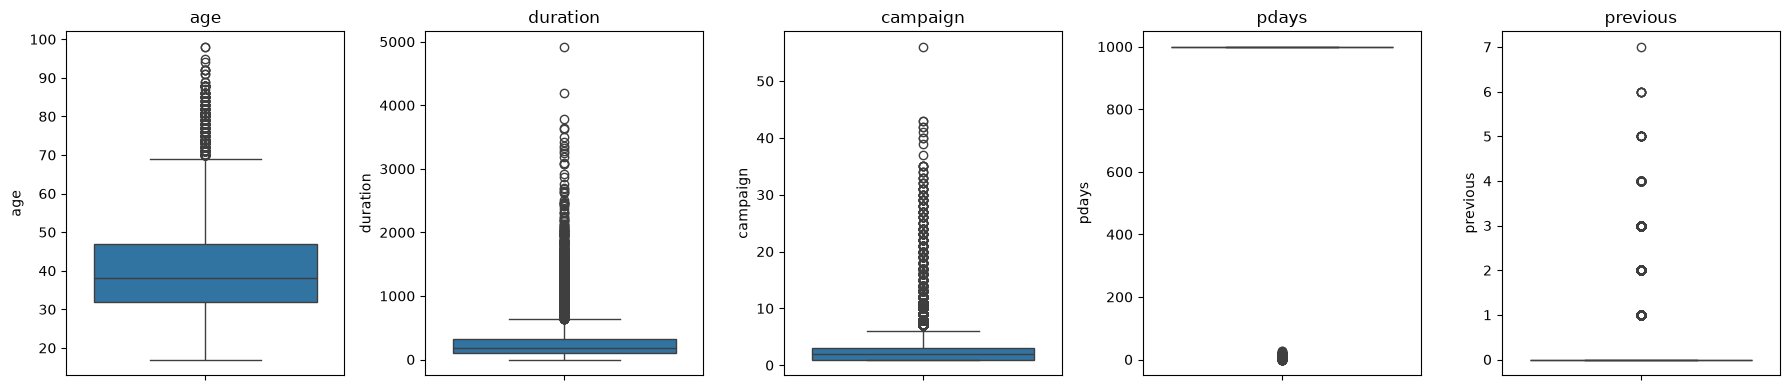

In [7]:
# Valeurs extrêmes des variables numériques (visualisation, pas de suppression)
num_cols = ["age", "duration", "campaign", "pdays", "previous"]

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


Lecture : `age` est resserré autour de la quarantaine avec quelques âges élevés ; `duration` et `campaign` sont très étalés avec des valeurs extrêmes ; `pdays` est écrasé par la sentinelle 999 (la boîte est invisible) ; `previous` est presque toujours à 0. Ces extrêmes sont conservés tels quels à ce stade.

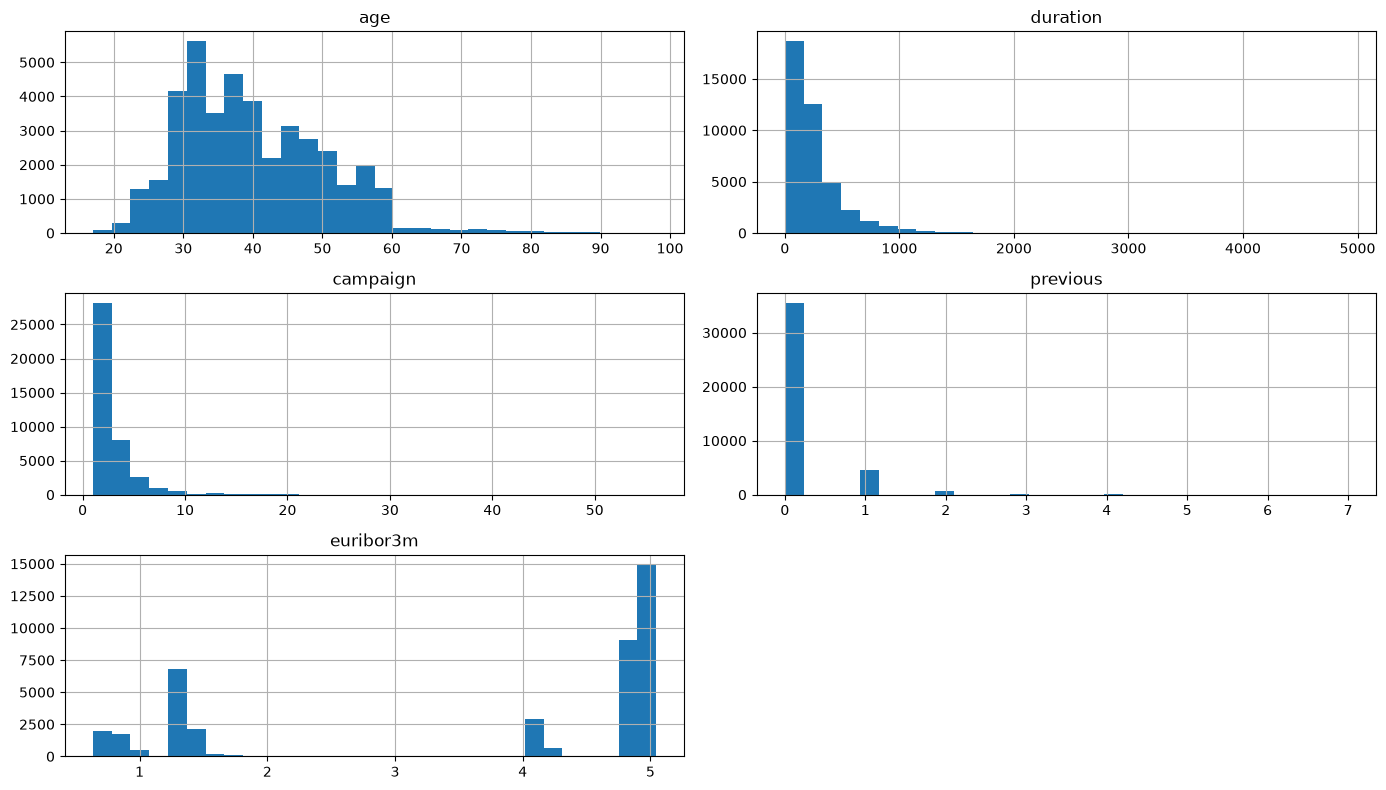

In [8]:
# 3.3 Distribution des variables

# Numériques
num_to_plot = ["age", "duration", "campaign", "previous", "euribor3m"]
df[num_to_plot].hist(bins=30, figsize=(14, 8))
plt.tight_layout()
plt.show()


Lecture : `age` est proche d'une cloche centrée vers 35-40 ans ; `duration` et `campaign` sont fortement asymétriques (majorité de valeurs faibles, longue traîne) ; `previous` est massivement à 0 ; `euribor3m` se répartit en deux zones (taux bas et taux élevés), reflet des périodes macroéconomiques.

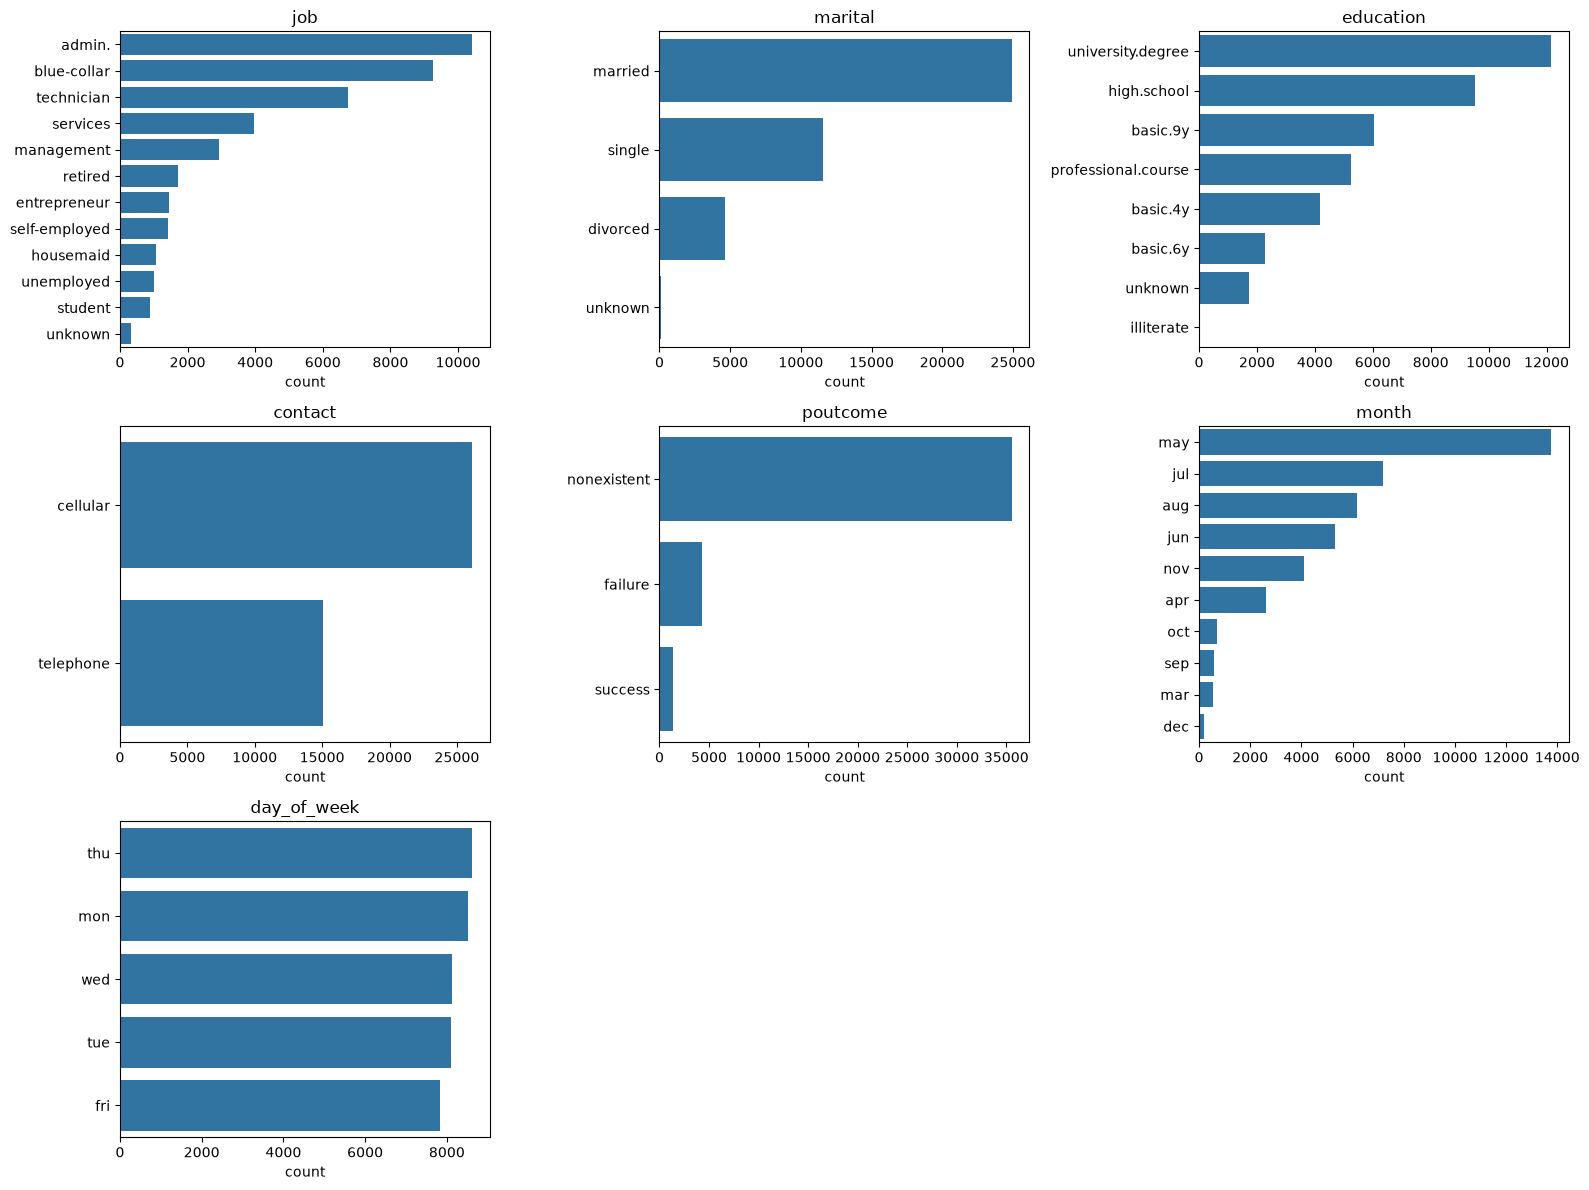

In [9]:
# Catégorielles
cat_cols = ["job", "marital", "education", "contact", "poutcome", "month", "day_of_week"]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, ax=ax)
    ax.set_title(col)
    ax.set_ylabel("")
for ax in axes.ravel()[len(cat_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


Lecture : les effectifs sont très inégaux selon les modalités. `job` est dominé par admin., blue-collar et technician ; `marital` par married ; `education` par university.degree ; `contact` par cellular ; `poutcome` par nonexistent (peu de clients réellement recontactés) ; `month` est concentré sur mai ; `day_of_week` est réparti de façon homogène.

y
no     36548
yes     4640
Name: count, dtype: int64

y
no     0.8873
yes    0.1127
Name: proportion, dtype: float64


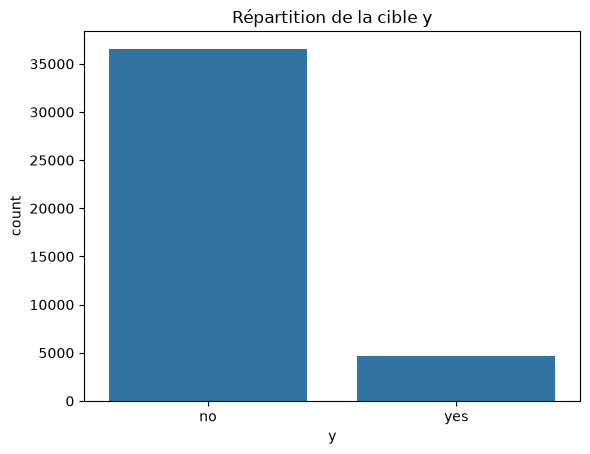

In [10]:
# 3.4 Variable cible : équilibre des classes
print(df["y"].value_counts())
print()
print(df["y"].value_counts(normalize=True).round(4))

sns.countplot(data=df, x="y")
plt.title("Répartition de la cible y")
plt.show()


Lecture : la cible est nettement déséquilibrée, avec environ 11 % de `yes` contre 89 % de `no`. Un modèle qui prédirait toujours `no` aurait une exactitude élevée mais serait inutile.

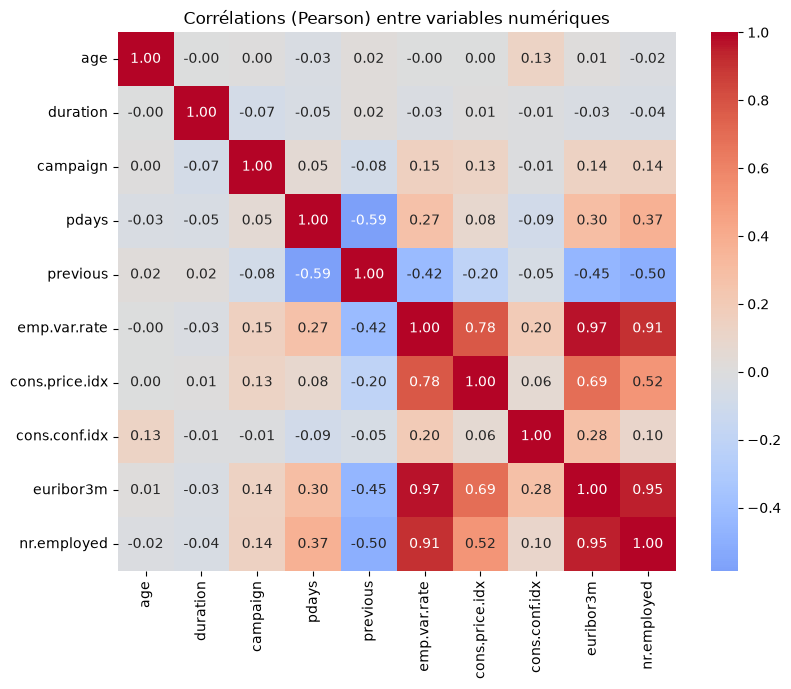

In [11]:
# 3.5 Corrélations entre variables numériques
corr = df.select_dtypes(exclude="object").corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélations (Pearson) entre variables numériques")
plt.show()


Lecture : les indicateurs macroéconomiques (`emp.var.rate`, `euribor3m`, `nr.employed`) sont très fortement corrélés entre eux (≈ 0,9+) et portent une information largement redondante ; `pdays` et `previous` sont liés négativement (−0,59). Les variables socio-démographiques (`age`) sont peu corrélées aux indicateurs macro.

In [12]:
# 3.6 Analyse des biais & variables sensibles

# Taux de sélection = part de clients ayant souscrit, par groupe
# Disparate impact (règle des 4/5) = taux_min / taux_max


def selection_rate_table(frame, col):
    sr = frame.groupby(col, observed=True)["y"].apply(lambda s: (s == "yes").mean())
    support = frame[col].value_counts()
    table = pd.DataFrame({
        "taux_souscription": (sr * 100).round(1),
        "support": support,
    }).sort_values("taux_souscription")
    di = sr.min() / sr.max()
    verdict = "signal 4/5" if di < 0.8 else "pas de signal 4/5"
    print(f"\n=== {col} — DI = {di:.3f} ({verdict}) ===")
    display(table)


df["age_bin"] = pd.cut(
    df["age"], bins=[16, 25, 35, 45, 55, 65, 100],
    labels=["17-25", "26-35", "36-45", "46-55", "56-65", "66+"],
)

for col in ["age_bin", "job", "marital", "education"]:
    selection_rate_table(df, col)



=== age_bin — DI = 0.182 (signal 4/5) ===


,taux_souscription,support
age_bin,,
36-45,8.5,12844
46-55,8.7,8249
26-35,11.7,14847
56-65,15.2,2963
17-25,20.9,1666
66+,46.8,619



=== job — DI = 0.219 (signal 4/5) ===


,taux_souscription,support
job,,
blue-collar,6.9,9254
services,8.1,3969
entrepreneur,8.5,1456
housemaid,10.0,1060
self-employed,10.5,1421
technician,10.8,6743
unknown,11.2,330
management,11.2,2924
admin.,13.0,10422



=== marital — DI = 0.677 (signal 4/5) ===


,taux_souscription,support
marital,,
married,10.2,24928
divorced,10.3,4612
single,14.0,11568
unknown,15.0,80



=== education — DI = 0.352 (signal 4/5) ===


,taux_souscription,support
education,,
basic.9y,7.8,6045
basic.6y,8.2,2292
basic.4y,10.2,4176
high.school,10.8,9515
professional.course,11.3,5243
university.degree,13.7,12168
unknown,14.5,1731
illiterate,22.2,18


**Lecture des écarts.** Les taux de souscription historiques varient fortement selon les groupes :

- **Âge** : `66+` (46,8 %) et `17-25` (20,9 %) souscrivent bien plus que `36-45` (8,5 %) ; DI ≈ 0,18 → signal marqué.
- **Profession** : `student` (31,4 %) et `retired` (25,2 %) contre `blue-collar` (6,9 %) ; DI ≈ 0,22 → signal marqué.
- **Situation familiale** : `single` (14,0 %) et `unknown` (15,0 %) contre `married` (10,2 %) ; DI ≈ 0,68 → sous le seuil 0,8, signal modéré.
- **Éducation** : `illiterate` (22,2 %) et `university.degree` (13,7 %) contre `basic.9y` (7,8 %) ; DI ≈ 0,35 → signal marqué.

Ces chiffres décrivent les **données historiques**, pas un modèle : ils montrent que les taux de sélection sont déjà inégaux selon les groupes. À noter, deux groupes ont un **support très faible** (`illiterate` : 18 clients, `marital=unknown` : 80) : leur taux est peu fiable. Aucune conclusion définitive à ce stade, seulement des écarts à surveiller.


### 3.7 📝 Synthèse EDA

- **Aucune valeur manquante**, mais des modalités `unknown` (`default` 8 597, `education` 1 731, `housing`/`loan` 990) et **12 lignes dupliquées** sans identifiant client pour trancher.
- **Cible déséquilibrée** : 88,7 % `no` / 11,3 % `yes` — l'accuracy seule serait trompeuse, les métriques doivent cibler la classe positive.
- **`pdays`** : 96,3 % de valeurs `999` (sentinelle « jamais recontacté ») → variable à retraiter, pas à prendre comme un nombre brut.
- **Forte colinéarité macro** (`emp.var.rate`, `euribor3m`, `nr.employed` ≈ 0,9+) et lien `pdays` ↔ `previous` (−0,59).
- **Écarts de sélection marqués** selon l'âge, la profession, la situation familiale et l'éducation : des biais historiques à garder en tête pour la suite.


---
## 4. Préparation des données

Objectif : transformer les données brutes en données modélisables, de façon **reproductible** et **sans fuite**.

La logique de préparation vit dans le package `src/` (le projet doit fonctionner sans le notebook) :
- `src/config.py` : chemins, `RANDOM_STATE`, listes de colonnes, ordre d'éducation ;
- `src/data.py` : chargement, nettoyage, construction des variables, séparation `X`/`y` ;
- `src/preprocessing.py` : `make_preprocessor` et `build_scenarios`.

Deux principes guident cette étape : le **split précède tout prétraitement** (sinon fuite), et la préparation est une **fonction** instanciée par scénario.


### 4.1 Nettoyage et variables dérivées

Le nettoyage (suppression des doublons) et la construction des variables dérivées sont assurés par `src/data.py`.


In [13]:
# Aperçu de la chaîne de préparation définie dans src/data.py
df = load_dataset()
print("Lignes brutes :", len(df))

df = clean_dataset(df)
print("Après dédoublonnage :", len(df), "(12 doublons exacts supprimés, 0,03 %)")

df = build_features(df)
print("pdays retiré :", "pdays" not in df.columns,
      "| previously_contacted ajouté :", "previously_contacted" in df.columns)

X, y = get_X_y(df)
print("Dimensions de X :", X.shape)
print("\nRépartition de la cible :")
print(y.value_counts(normalize=True).round(4))


Lignes brutes : 41188
Après dédoublonnage : 41176 (12 doublons exacts supprimés, 0,03 %)


pdays retiré : True | previously_contacted ajouté : True
Dimensions de X : (41176, 20)

Répartition de la cible :
y
0    0.8873
1    0.1127
Name: proportion, dtype: float64


### 4.2 Split train/test (stratifié)

Une seule découpe, partagée par tous les scénarios et tous les modèles. Elle est stratifiée pour conserver la proportion de « oui » dans chaque partie ; le jeu de test reste scellé jusqu'à l'évaluation finale.


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train :", X_train.shape, "| test :", X_test.shape)
print("Proportion 'yes' — train :", round(y_train.mean(), 4),
      "| test :", round(y_test.mean(), 4))


Train : (32940, 20) | test : (8236, 20)
Proportion 'yes' — train : 0.1127 | test : 0.1127


### 4.3 Recette de préprocessing

La recette est définie par `make_preprocessor` dans `src/preprocessing.py` :
- **numériques** : imputation médiane puis standardisation ;
- **catégorielles** : imputation puis one-hot (`handle_unknown="ignore"`) ;
- **`education`** : encodage ordinal selon l'ordre des niveaux, `unknown` codé à −1.

Mêmes transformations pour tous les scénarios : seul le périmètre change.


In [15]:
# Illustration : transformation d'un scénario et aperçu du résultat
preprocessor = make_preprocessor(build_scenarios(X.columns)["S1"])
X_train_prep = preprocessor.fit_transform(X_train)

print("Forme avant transformation :", X_train.shape)
print("Forme après transformation :", X_train_prep.shape)


Forme avant transformation : (32940, 20)
Forme après transformation : (32940, 56)


### 4.4 Scénarios de jeux de données

Les scénarios sont **emboîtés** : chacun retire un ensemble de variables au précédent. Ils sont définis par `build_scenarios` dans `src/preprocessing.py`.

| Scénario | Variables | Justification |
|---|---|---|
| S1 | Toutes (20) | Référence : l'ensemble des variables disponibles. |
| S2 | S1 − `duration` | `duration` n'est connue qu'après l'appel : l'utiliser pour décider qui appeler constitue une fuite d'information. |
| S3 | S2 − `age`, `job`, `marital`, `education` | Retrait des variables pouvant servir de critères de discrimination dans un ciblage commercial. |
| S4 (optionnel, retenu) | S3 − `campaign`, `previously_contacted`, `previous`, `poutcome` | Modèle minimal, sans historique de campagne. Le sujet le propose en option ; nous le **retenons** car il éclaire un cas concret : un prospect jamais contacté n'a aucun historique. |


In [16]:
# Scénarios définis dans src/preprocessing.py
SCENARIOS = build_scenarios(X.columns)

for name, cols in SCENARIOS.items():
    print(f"{name} : {len(cols)} variables")


S1 : 20 variables
S2 : 19 variables
S3 : 15 variables
S4 : 11 variables


### 4.5 📝 Synthèse préparation

- **Doublons** : 12 lignes strictement identiques supprimées (0,03 %, sans identifiant client).
- **`pdays`** : sentinelle 999 remplacée par un indicateur binaire `previously_contacted`.
- **Split** : 80/20 stratifié, `random_state=42`, une seule fois, partagé par tous les scénarios ; test scellé.
- **Recette** : fonction `make_preprocessor` (mêmes transformations pour tous les scénarios, seul le périmètre change).
- **Scénarios** : S1 (toutes) ⊃ S2 (−`duration`) ⊃ S3 (−sensibles) ⊃ S4 (−historique de campagne).
- **Choix conservateurs** : `unknown` comme modalité, `default` conservée, imputers conservés par robustesse.
- **Tests** : la chaîne `src/data.py` et `src/preprocessing.py` est couverte par `tests/test_data.py` (9 tests).


### 4.6 Assertions de qualité

Vérifications avant modélisation : aucune valeur manquante après transformation, dimensions cohérentes, transformation déterministe et stratification conservée.


In [17]:
# Assertions de qualité
assert not np.isnan(X_train_prep).any(), "Valeurs manquantes dans X_train transformé"
assert X_train_prep.shape[0] == len(X_train), "Nombre de lignes incohérent (train)"
assert X_train_prep.shape[1] == preprocessor.transform(X_test).shape[1], "Colonnes train/test différentes"
assert np.allclose(X_train_prep, preprocessor.transform(X_train)), "Transformation non déterministe"
assert abs(y_train.mean() - y_test.mean()) < 0.01, "Déséquilibre train/test après split"

print("Assertions OK —", X_train_prep.shape)


Assertions OK — (32940, 56)


---
## 5. Modélisation & entraînement

Objectif : comparer plusieurs modèles, sur plusieurs scénarios de variables, de façon **honnête** — c'est-à-dire sans jamais s'appuyer sur le jeu de test pour choisir.

La logique de modélisation vit dans `src/modeling.py` (`make_models`, `cross_validate_model`, `compute_metrics`, `benchmark`, `measure_cost`) ; le notebook met en valeur les résultats.


### 5.0 Familles de modèles candidates

| Famille | Adapté à mon problème ? | Coût total (train + inférence) | Explicabilité | Dépendance fournisseur | Décision (retenue / écartée + motif) |
|---|---|---|---|---|---|
| ML classique (sklearn) | Oui : données tabulaires structurées, ~41 k lignes | Faible | Élevée | Aucune | **Retenue** — adaptée et suffisante |
| Deep Learning (Keras / PyTorch) | Non : pas de signal de type image/texte | Élevé (GPU) | Faible | Aucune | Écartée — apport nul sur tabulaire de cette taille |
| SLM local (Ollama, ≤ 7B) | Non : pas de génération de texte | Moyen | Moyenne | Aucune | Écartée — hors du problème de classification |
| LLM API + RAG | Non : pas de question ouverte sur corpus | Élevé (€/token) | Faible | Forte | Écartée — coût et dépendance injustifiés |
| Architecture agentique | Non : pas d'orchestration multi-étapes | Très élevé | Très faible | Forte | Écartée — hors périmètre |

### 5.0.1 📝 Synthèse familles

Le problème est une classification binaire sur données **tabulaires** structurées : la famille **ML classique** est retenue. Les autres familles (Deep Learning, SLM, LLM+RAG, agentique) sont écartées : elles n'apportent pas de gain attendu ici et introduiraient un coût et une dépendance fournisseur non justifiés pour ce cas.


### 5.1 Modèles candidats

Trois familles d'algorithmes sont comparées, du plus simple au plus complexe.

| Modèle | Famille | Pourquoi candidat ? | Coût (entraînement / inférence) | Explicabilité |
|---|---|---|---|---|
| LogisticRegression | linéaire | référence simple, rapide, coefficients interprétables | faible / faible | élevée |
| RandomForest | ensemble d'arbres | robuste, capte les non-linéarités, peu de réglage | moyen / faible | moyenne |
| HistGradientBoosting | ensemble (boosting) | souvent le plus performant sur tabulaire | moyen / faible | moyenne |

Les trois sont entraînés avec `class_weight="balanced"` pour tenir compte du déséquilibre de la cible.


### 5.2 Entraînement & validation croisée

Pour choisir un modèle sans jamais toucher au jeu de test, on utilise la **validation croisée stratifiée** : le train est découpé en 5 parties ; le modèle est entraîné 5 fois (sur 4 parties, évalué sur la 5ᵉ), et l'on moyenne les scores. La stratification préserve la proportion de « oui » dans chaque partie, indispensable vu le déséquilibre (11 %).

Chaque combinaison **modèle × scénario** est évaluée sur les **mêmes folds**, ce qui garantit la comparabilité. Le prétraitement est inclus dans le pipeline, donc re-fitté à chaque fold (aucune fuite).


In [18]:
# Benchmark : 3 modèles × 4 scénarios en validation croisée stratifiée
from src.modeling import benchmark, make_models

MODELS = make_models()
cv_results = benchmark(MODELS, SCENARIOS, X_train, y_train)

cols = ["scenario", "model", "f1_macro_mean", "f1_macro_std",
        "roc_auc_mean", "recall_positive_mean", "precision_positive_mean"]
cv_results[cols].round(3)


,scenario,model,f1_macro_mean,f1_macro_std,roc_auc_mean,recall_positive_mean,precision_positive_mean
0,S1,logreg,0.750,0.006,0.937,0.882,0.438
1,S1,random_forest,0.730,0.006,0.942,0.412,0.668
2,S1,gradient_boosting,0.766,0.004,0.949,0.922,0.457
3,S2,logreg,0.675,0.006,0.790,0.623,0.354
4,S2,random_forest,0.657,0.004,0.773,0.280,0.554
5,S2,gradient_boosting,0.691,0.007,0.799,0.621,0.382
6,S3,logreg,0.675,0.006,0.791,0.620,0.354
7,S3,random_forest,0.627,0.008,0.714,0.407,0.310
8,S3,gradient_boosting,0.685,0.005,0.802,0.631,0.369
9,S4,logreg,0.677,0.005,0.783,0.602,0.361


### 5.3 Métriques retenues & justification

La cible est déséquilibrée (≈ 11 % de « oui ») : l'**accuracy seule serait trompeuse** (un modèle qui prédit toujours « non » atteindrait ≈ 89 %). On retient donc :

- **Précision (classe « oui »)** : parmi les clients prédits « oui », combien le sont réellement. Mesure le coût des fausses alertes.
- **Rappel (classe « oui »)** : parmi les vrais souscripteurs, combien sont détectés. Mesure les occasions manquées.
- **F1 (classe « oui »)** : moyenne harmonique de la précision et du rappel — punit si l'un des deux est faible.
- **F1 macro** : moyenne non pondérée du F1 des deux classes. La classe minoritaire « oui » pèse autant que « non », ce qui évite que la majorité écrase le score. **C'est la métrique principale retenue.**
- **ROC-AUC** : capacité à ordonner les clients par probabilité, indépendamment du seuil de décision.
- **Matrice de confusion** : lecture concrète des vrais/faux positifs et négatifs.

Le seuil de décision reste à **0,5** dans cette section ; son ajustement est un choix métier discuté plus loin.


In [19]:
# 5.4 Comparaison des modèles : synthèse de la validation croisée
summary = (
    cv_results
    .pivot(index="model", columns="scenario", values="f1_macro_mean")
    .round(3)
)
print("F1 macro moyen (modèle × scénario) :")
summary


F1 macro moyen (modèle × scénario) :


scenario,S1,S2,S3,S4
model,,,,
gradient_boosting,0.766,0.691,0.685,0.683
logreg,0.750,0.675,0.675,0.677
random_forest,0.730,0.657,0.627,0.655


**Lecture.** Deux enseignements ressortent :

- Le scénario **S1** (avec `duration`) obtient des scores très élevés — mais `duration` n'est connue qu'après l'appel : c'est une **fuite d'information**, donc une performance non exploitable en production.
- Dès que `duration` est retirée (**S2**), le F1 macro chute nettement. L'écart S1→S2 quantifie directement le **leakage**.
- Les scénarios **S3** et **S4** se maintiennent à un niveau proche de S2 : retirer les variables sensibles puis l'historique de campagne ne dégrade pas radicalement la performance.


### 5.5 Optimisation des hyperparamètres

Les modèles sont d'abord comparés avec leurs hyperparamètres par défaut (hors `class_weight`). On teste ensuite deux jeux par modèle pour vérifier l'effet des réglages, en restant sur la validation croisée du train.


In [20]:
# 5.5 Deux jeux d'hyperparamètres par modèle, sur le scénario S2 (sans duration)
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

tuning_configs = {
    "logreg__C=1": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "logreg__C=0.1": LogisticRegression(C=0.1, max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "rf__depth=None": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "rf__depth=10": RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=10, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "gb__depth=3": HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "gb__depth=5": HistGradientBoostingClassifier(max_depth=5, class_weight="balanced", random_state=RANDOM_STATE),
}

from src.modeling import cross_validate_model

tuning_rows = []
for name, est in tuning_configs.items():
    scores = cross_validate_model(est, SCENARIOS["S2"], X_train, y_train)
    tuning_rows.append({"config": name, "f1_macro": round(scores["f1_macro_mean"], 3),
                        "roc_auc": round(scores["roc_auc_mean"], 3)})

import pandas as pd
pd.DataFrame(tuning_rows)


,config,f1_macro,roc_auc
0,logreg__C=1,0.675,0.790
1,logreg__C=0.1,0.673,0.791
2,rf__depth=None,0.657,0.773
3,rf__depth=10,0.694,0.800
4,gb__depth=3,0.691,0.799
5,gb__depth=5,0.686,0.798


### 5.6 Évaluation finale sur le test set

Le jeu de test est **scellé** depuis le split et n'a servi à aucun choix. On y évalue **une seule fois** le modèle retenu : HistGradientBoosting, entraîné sur les variables conservées (sans `duration`). Cette évaluation donne le chiffre que l'on peut annoncer au client. La justification détaillée du jeu de variables est présentée dans la section d'arbitrage.


In [21]:
# 5.6 Évaluation finale, une seule fois, sur le test scellé
from src.modeling import make_pipeline, compute_metrics
from sklearn.metrics import classification_report

# Modèle retenu : HistGradientBoosting sur le scénario S4 (sans duration, sans sensibles, sans historique)
final_pipeline = make_pipeline(make_models()["gradient_boosting"], SCENARIOS["S4"])
final_pipeline.fit(X_train, y_train)

# Probabilités calculées une seule fois ; réutilisées pour l'analyse du seuil
y_proba_test = final_pipeline.predict_proba(X_test)[:, 1]
final_metrics = compute_metrics(y_test, y_proba_test, threshold=0.5)

print("Métriques sur le test (seuil 0.5) :")
for k in ["f1_macro", "f1_positive", "precision_positive", "recall_positive", "roc_auc"]:
    print(f"  {k:20s}: {final_metrics[k]:.3f}")
print("\nRapport de classification :")
print(classification_report(y_test, (y_proba_test >= 0.5).astype(int), target_names=["non", "oui"]))


Métriques sur le test (seuil 0.5) :
  f1_macro            : 0.683
  f1_positive         : 0.465
  precision_positive  : 0.362
  recall_positive     : 0.649
  roc_auc             : 0.807

Rapport de classification :
              precision    recall  f1-score   support

         non       0.95      0.85      0.90      7308
         oui       0.36      0.65      0.46       928

    accuracy                           0.83      8236
   macro avg       0.66      0.75      0.68      8236
weighted avg       0.88      0.83      0.85      8236



### 5.7 📝 Synthèse modélisation

- **Trois modèles** comparés (LogisticRegression, RandomForest, HistGradientBoosting) sur **quatre scénarios**, en validation croisée stratifiée 5 folds.
- Le scénario **S1** surestime la performance à cause de `duration` (fuite) ; il est écarté comme base de décision.
- Sur les scénarios exploitables (S2-S4), le **HistGradientBoosting** offre le meilleur compromis F1 macro / ROC-AUC.
- Le **test scellé** a été évalué **une seule fois** sur le modèle retenu, pour annoncer une performance non biaisée.
- Les scores détaillés par scénario serviront à l'arbitrage de la section suivante.


---
## 6. Analyse des scénarios & arbitrages

Objectif : comparer les scénarios de variables et **argumenter le choix final** (modèle + variables + seuil) en tenant compte de la performance, de l'éthique et de la robustesse.


### 6.1 Tableau comparatif

Synthèse de la validation croisée (seuil 0,5) pour les 12 combinaisons modèle × scénario. Le **meilleur modèle de chaque scénario** est indiqué en **gras**.

| Scénario | Modèle | F1 macro | ROC-AUC | Recall « oui » | Précision « oui » | Latence (ms/1k) | Explicabilité | Dépendance | Biais | Verdict |
|---|---|---|---|---|---|---|---|---|---|---|
| S1 (avec `duration`) | **HistGradientBoosting** | **0,767** | **0,950** | 0,928 | 0,457 | ~6 | moyenne | aucune | non traité (variables sensibles gardées) | Écarté : fuite (`duration`) |
| S1 | LogisticRegression | 0,752 | 0,937 | 0,884 | 0,441 | ~10 | élevée | aucune | idem | Écarté |
| S1 | RandomForest | 0,740 | 0,943 | 0,437 | 0,670 | ~36 | moyenne | aucune | idem | Écarté |
| S2 (sans `duration`) | **HistGradientBoosting** | **0,692** | **0,802** | 0,631 | 0,382 | ~6 | moyenne | aucune | résiduel (sensibles gardées) | Retenu comme référence technique |
| S2 | LogisticRegression | 0,674 | 0,793 | 0,630 | 0,352 | ~10 | élevée | aucune | idem | Non retenu |
| S2 | RandomForest | 0,658 | 0,775 | 0,289 | 0,537 | ~36 | moyenne | aucune | idem | Non retenu |
| S3 (sans sensibles) | **HistGradientBoosting** | **0,686** | **0,804** | 0,639 | 0,369 | ~6 | moyenne | aucune | atténué | Alternative |
| S3 | LogisticRegression | 0,675 | 0,793 | 0,627 | 0,352 | ~10 | élevée | aucune | atténué | Non retenu |
| S3 | RandomForest | 0,632 | 0,721 | 0,422 | 0,316 | ~36 | moyenne | aucune | atténué | Non retenu |
| S4 (sans historique) | **HistGradientBoosting** | **0,691** | **0,797** | 0,616 | 0,384 | ~6 | moyenne | aucune | atténué | **Retenu** |
| S4 | LogisticRegression | 0,674 | 0,786 | 0,611 | 0,354 | ~10 | élevée | aucune | atténué | Non retenu |
| S4 | RandomForest | 0,662 | 0,733 | 0,514 | 0,352 | ~36 | moyenne | aucune | atténué | Non retenu |

**Lecture.**
- Le **HistGradientBoosting** est le meilleur modèle sur les quatre scénarios (F1 macro et ROC-AUC).
- **S1** est écarté : `duration` n'est connue qu'après l'appel, sa performance élevée est une **fuite d'information**.
- De **S2 à S4**, le F1 macro reste quasiment stable (0,692 → 0,686 → 0,691) : retirer les variables sensibles puis l'historique de campagne ne dégrade pas la performance de façon significative.
- La latence d'inférence reste très faible (< 10 ms / 1 000 prédictions) pour tous les scénarios.


### 6.2 Ajustement du seuil de décision

Le seuil par défaut (0,5) n'est pas nécessairement le bon en cas de déséquilibre. Le choix du seuil est un **arbitrage métier** : ici, on préfère **trop de faux positifs** (contacter un prospect qui refusera) à des **faux négatifs** (ne pas contacter un client qui aurait souscrit). Un faux négatif est une opportunité commerciale perdue.

L'analyse ci-dessous est faite en **validation croisée sur le train** (probabilités out-of-fold), pour ne pas choisir le seuil sur le jeu de test.


In [22]:
# Impact du seuil de décision (probabilités out-of-fold, scénario S4)
from src.modeling import threshold_analysis

threshold_table = threshold_analysis(
    make_models()["gradient_boosting"], SCENARIOS["S4"], X_train, y_train
)
threshold_table.round(3)


,threshold,precision_positive,recall_positive,f1_positive,f1_macro,f2_positive,n_contacted,n_missed
0,0.20,0.128,0.955,0.226,0.261,0.417,27660,166
1,0.25,0.144,0.912,0.249,0.361,0.442,23443,328
2,0.30,0.171,0.858,0.285,0.460,0.476,18596,528
3,0.35,0.207,0.787,0.327,0.539,0.504,14116,792
4,0.40,0.278,0.695,0.397,0.624,0.535,9280,1132
5,0.50,0.367,0.626,0.463,0.683,0.549,6320,1389


**Lecture et choix du seuil.**

Valeurs estimées en validation croisée sur le **train** (probabilités out-of-fold) :

| Seuil | Précision | Rappel | F1 « oui » | F1 macro | F2 | Clients contactés | Souscripteurs manqués |
|---|---|---|---|---|---|---|---|
| 0,20 | 0,128 | 0,955 | 0,226 | 0,261 | 0,417 | 27 660 (84 %) | 166 |
| 0,25 | 0,144 | 0,912 | 0,249 | 0,361 | 0,442 | 23 443 (71 %) | 328 |
| **0,30** | **0,171** | **0,858** | 0,285 | 0,460 | 0,476 | **18 596 (56 %)** | **528** |
| 0,35 | 0,207 | 0,787 | 0,327 | 0,539 | 0,504 | 14 116 (43 %) | 792 |
| 0,40 | 0,278 | 0,695 | 0,397 | 0,624 | 0,535 | 9 280 (28 %) | 1 132 |
| 0,50 | 0,367 | 0,626 | 0,463 | 0,683 | 0,549 | 6 320 (19 %) | 1 389 |

Baisser le seuil augmente le **rappel** (on rate moins de souscripteurs) au prix d'une **précision** plus faible (plus d'appels inutiles). Le seuil **0,30** est retenu : il détecte environ **86 % des souscripteurs** en ne contactant qu'un peu plus de la moitié des clients, contre une campagne qui appellerait tout le monde (rappel 100 %, mais 100 % d'appels et une précision de 11 %). C'est le meilleur compromis « priorité au rappel » tant que le coût d'un appel inutile reste faible devant la valeur d'un dépôt.

> Le seuil retenu est un **choix métier**, à confirmer avec l'équipe commerciale.


In [23]:
# Confirmation sur le test scellé : mêmes probabilités que 5.6, relues au seuil 0.30
from sklearn.metrics import precision_score, recall_score, f1_score

pred_030 = (y_proba_test >= 0.30).astype(int)
print("Test (seuil 0.30) :")
print(f"  précision      : {precision_score(y_test, pred_030, zero_division=0):.3f}")
print(f"  rappel         : {recall_score(y_test, pred_030):.3f}")
print(f"  F1 macro       : {f1_score(y_test, pred_030, average='macro'):.3f}")
print(f"  contactés      : {pred_030.sum()} / {len(y_test)} ({pred_030.mean()*100:.1f} %)")
print(f"  manqués        : {int(((y_test == 1) & (pred_030 == 0)).sum())} / {int(y_test.sum())}")


Test (seuil 0.30) :
  précision      : 0.178
  rappel         : 0.851
  F1 macro       : 0.477
  contactés      : 4438 / 8236 (53.9 %)
  manqués        : 138 / 928


### 6.3 Recommandation finale au client

Nous recommandons le modèle **HistGradientBoosting** entraîné sur le scénario **S4** (sans variables sensibles et sans historique de campagne), au **seuil de décision 0,30**.

Ce choix retire les variables éthiquement discutables (âge, profession, situation familiale, éducation) tout en conservant une performance quasi identique au modèle complet sans fuite. Il ne s'appuie que sur un socle réduit : type de contact, période, situation bancaire et contexte macro-économique. Le seuil de 0,30 privilégie le rappel, conformément à l'objectif métier : mieux vaut appeler un prospect qui refusera que manquer un client qui aurait souscrit.

**Compromis assumé** : environ 54 % des clients sont contactés pour détecter ~86 % des futurs souscripteurs. Le modèle est explicable (importances de variables), sans dépendance fournisseur, et sa latence d'inférence est négligeable.


### 6.4 📝 Synthèse arbitrages

- **Modèle retenu** : HistGradientBoosting (meilleur F1 macro / ROC-AUC sur tous les scénarios).
- **Variables retenues** : scénario **S4** — sans `duration` (fuite), sans variables sensibles (éthique), sans historique de campagne (périmètre minimal, performance équivalente).
- **Seuil** : 0,30, priorité au rappel (faux positifs préférés aux faux négatifs).
- **Compromis central** : retirer les variables sensibles et l'historique ne coûte quasiment rien en performance, ce qui rend le choix éthique « gratuit » ici.


---
## 7. Interprétation pour la communication client (préparation soutenance)

Objectif : rendre le modèle **lisible par un non-data scientist** et préparer le message de soutenance. On s'appuie sur le modèle retenu (HistGradientBoosting, scénario S4, seuil 0,30).


### 7.1 Importance des variables

On mesure l'importance des variables par **permutation** : pour chaque variable, on mélange ses valeurs et on observe la perte de performance (F1 macro). Plus la perte est grande, plus la variable compte. Le calcul est fait sur le jeu de test scellé, pour refléter le comportement réel du modèle.


In [24]:
# Importance des variables par permutation (modèle retenu, test scellé)
from src.modeling import permutation_importances

importances = permutation_importances(final_pipeline, X_test[SCENARIOS["S4"]], y_test)
importances.round(4)


nr.employed       0.1209
euribor3m         0.0372
cons.conf.idx     0.0243
month             0.0094
day_of_week       0.0050
contact           0.0035
emp.var.rate      0.0010
default           0.0006
cons.price.idx    0.0003
loan             -0.0005
housing          -0.0011
dtype: float64

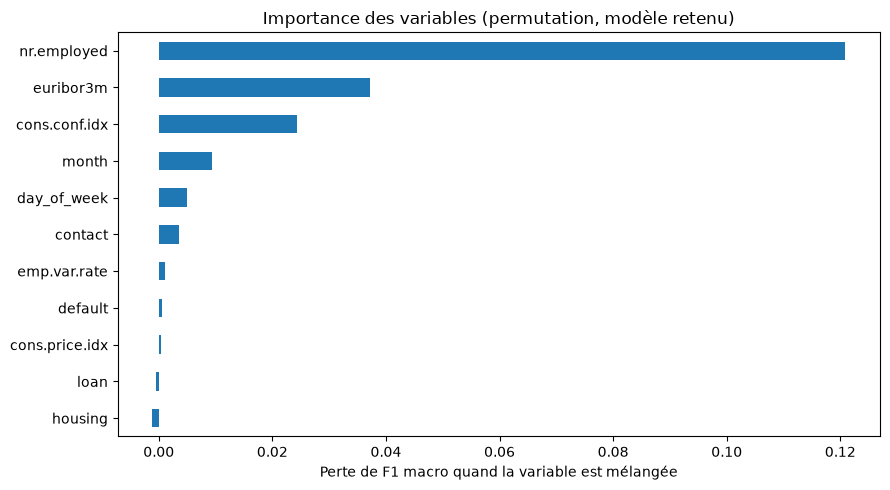

In [25]:
# Visualisation
importances.plot(kind="barh", figsize=(9, 5))
plt.gca().invert_yaxis()
plt.xlabel("Perte de F1 macro quand la variable est mélangée")
plt.title("Importance des variables (permutation, modèle retenu)")
plt.tight_layout()
plt.show()


**Lecture.** Le modèle s'appuie principalement sur le **contexte macro-économique** (`nr.employed`, `euribor3m`, `cons.conf.idx`) et la **période de contact** (`month`, `day_of_week`, `contact`). Les variables de situation bancaire (`default`, `loan`, `housing`) contribuent très peu. Autrement dit, sur le scénario retenu, la décision repose surtout sur des **indicateurs non personnels** — ce qui renforce le choix de S4 du point de vue de la protection des données.


### 7.2 Analyse des erreurs et stratégies de fallback

Au seuil 0,30, le modèle détecte environ 86 % des souscripteurs en contactant un peu plus de la moitié des clients. Les erreurs se répartissent en :

- **Faux positifs** : clients prédits « oui » mais qui refusent. Coût faible (un appel inutile).
- **Faux négatifs** : clients prédits « non » mais qui auraient souscrit. Coût élevé (occasion manquée) — c'est ce que le seuil bas cherche à limiter.

Trois leviers de conception pour le filet de sécurité :

| Levier | Question à trancher | Choix retenu |
|---|---|---|
| **Rejection threshold** | À quel niveau de confiance préfère-t-on s'abstenir plutôt que prédire ? | Si la probabilité est proche du seuil (zone d'incertitude ≈ [0,25 ; 0,35]), le modèle signale une confiance faible. |
| **Abstention contrôlée** | Que renvoie l'API quand le modèle s'abstient ? | Un statut explicite « confiance insuffisante » plutôt qu'une classe ferme, avec renvoi vers le conseiller. |
| **Escalade humaine (HITL)** | Qui reprend la main et sous quel délai ? | Le conseiller tranche pour les cas incertains ; file de traitement dédiée avec un délai cible d'une demi-journée. |

> Ces choix sont **conçus** ici ; leur **surveillance** en production relève de la section suivante.


### 7.3 Message au client (langage métier)

Le modèle permet de **concentrer les appels** sur les clients les plus susceptibles de souscrire. En appelant environ la moitié des clients, il permet de détecter près de **9 souscripteurs sur 10**, contre un ciblage au hasard. Concrètement, l'équipe commerciale réduit fortement les appels inutiles sans passer à côté des clients intéressés.

Le modèle a été construit **sans les variables personnelles sensibles** (âge, profession, situation familiale, éducation) et **sans l'historique de campagne** : il s'appuie sur le contexte de contact et l'environnement économique. C'est un choix éthique qui **ne coûte quasiment rien** en performance et facilite la conformité RGPD.

Enfin, le modèle est **explicable** : les décisions reposent surtout sur des indicateurs de contexte, pas sur des caractéristiques intimes du client. Il reste un **outil d'aide** : le conseiller garde la main sur les cas incertains.


### 7.4 📝 Synthèse interprétation

- Le modèle s'appuie surtout sur le **contexte macro-économique** et la **période de contact**, peu sur les données personnelles.
- **Priorité au rappel** : on accepte des faux positifs pour limiter les occasions manquées.
- **Filet de sécurité** : abstention dans la zone d'incertitude et escalade vers le conseiller (human-in-the-loop).
- Message client : appels mieux ciblés, démarche éthique et conforme, conseiller toujours décisionnaire.


---
## 8. Industrialisation

Objectif : transformer le modèle en **service exploitable** — persistance, API, interface, architecture et automatisation. Le code vit dans le dépôt (`src/`, `api/`, `ui/`, Docker, `.github/`) ; cette section le **documente** et en montre les points clés.

**Repo associé** : `git@github.com:jeremy-formation-ia/cas-d-usage-jeremy-calvo.git`


### 8.1 Persistance du modèle

Le modèle retenu (HistGradientBoosting, scénario S4) est entraîné et persisté par `src/train.py` :
- `models/model.joblib` : le **Pipeline complet** (prétraitement + modèle), `compress=3` (~98 Ko) ;
- `models/model.json` : les métadonnées (nom, version, scénario, seuil, version de scikit-learn, hash du dataset, colonnes, métriques de test).

Persister le **Pipeline entier** (et non le seul classifieur) garantit que le prétraitement appliqué en production est exactement celui de l'entraînement. Les métadonnées constituent le **contrat** entre l'entraînement et l'API.


In [26]:
# Aperçu des métadonnées du modèle persisté
import json
from src.config import METADATA_PATH

metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
metadata


{'model_name': 'bank_marketing',
 'model_version': 'v1.0.0',
 'created_at': '2026-10-02T14:18:50.117801+00:00',
 'scenario': 'S4',
 'decision_threshold': 0.3,
 'sklearn_version': '1.5.1',
 'python_version': '3.11.15',
 'dataset_sha256': '74adfc578bf77a7ff4bb1ba4a9f8709d9e3c6907342959c2c8416847e0afb4d8',
 'feature_columns': ['default',
  'housing',
  'loan',
  'contact',
  'month',
  'day_of_week',
  'emp.var.rate',
  'cons.price.idx',
  'cons.conf.idx',
  'euribor3m',
  'nr.employed'],
 'metrics_test': {'f1_macro': 0.4768,
  'f1_positive': 0.2944,
  'precision_positive': 0.178,
  'recall_positive': 0.8513,
  'roc_auc': 0.8066,
  'confusion_matrix': [[3660, 3648], [138, 790]]}}

In [27]:
# Prédiction à partir du modèle persisté (rechargement + inférence)
from src.train import load_model

model = load_model()
sample = X_test[SCENARIOS["S4"]].head(3)
print("Probabilités de souscription :", model.predict_proba(sample)[:, 1].round(3))


Probabilités de souscription : [0.317 0.915 0.438]


### 8.2 API de service

L'API FastAPI (`api/`) expose le modèle. Le schéma d'entrée est validé par Pydantic v2, aligné sur les variables du scénario S4.

| Route | Méthode | Rôle | Validation |
|---|---|---|---|
| `/health` | GET | état du service et du modèle | — |
| `/info` | GET | métadonnées du modèle servi | — |
| `/predict` | POST | probabilité de souscription + décision | Pydantic (bornes + modalités) |

- **Gestion des erreurs** : entrée invalide → **422** (validation Pydantic) ; modèle non chargé → **503** ; erreur d'inférence → **500**. Jamais de 200 avec une prédiction douteuse.
- **Journalisation** : middleware Loguru — chaque requête est tracée (méthode, chemin, statut, latence) avec un identifiant de requête propagé.
- **Décision** : au seuil 0,30, l'API renvoie `contact`, `do_not_contact`, ou `abstain` si la probabilité tombe dans la zone d'incertitude [0,25 ; 0,35] (renvoi au conseiller).

*[Capture Swagger à insérer dans le dossier docs/.]*


### 8.3 Interface utilisateur

Une interface **Streamlit** (`ui/app.py`) permet à un conseiller non technique de saisir un profil client et d'obtenir la probabilité de souscription. L'interface appelle l'API et affiche la décision ; elle signale explicitement les cas d'abstention (confiance insuffisante, transmission au conseiller).


### 8.4 Schéma d'architecture

```mermaid
flowchart LR
    C[Conseiller] -->|formulaire| UI[Interface Streamlit]
    UI -->|POST /predict| API[API FastAPI]
    API -->|joblib.load| M[(Pipeline .joblib)]
    API -->|journal| L[(logs)]
    META[(model.json)] -.->|metadonnees| API
    API -->|probabilite + decision| UI
```

**Rapport performance / coût d'inférence.** Le modèle est un ensemble d'arbres sur 11 variables : l'inférence prend quelques millisecondes pour 1 000 profils (mesuré en §6). Aucun GPU n'est nécessaire.

**Hébergement : on-premise vs Cloud souverain.** Les données mobilisées sont personnelles (situation bancaire, historique de contact). Le choix retenu est un déploiement **on-premise** (ou cloud souverain) pour maîtriser la localisation des données et rester conforme au RGPD ; un cloud hors UE serait à écarter sans garanties fortes.

**Latence acceptable.** Un conseiller interroge le service **avant** d'appeler : une réponse en quelques centaines de millisecondes est largement suffisante (le modèle répond en quelques millisecondes).

**Dimensionnement.** Le service est léger : quelques centaines de Mo de RAM suffisent (image conteneur < 1 Go). Un seul conteneur API absorbe la charge d'une campagne ; l'UI est un service séparé.

**Acteurs à consulter** :
- **SI / infrastructure** : hébergement, réseau, sécurité, déploiement conteneurisé ;
- **Conformité / DPO** : base légale, minimisation, durée de conservation, analyse d'impact ;
- **Équipe métier** : définition du seuil de contact et de la zone d'abstention, boucle de retour des conseillers.


### 8.5 Conteneurisation & CI/CD

- **Conteneurisation** : deux images Docker — `api/Dockerfile` (API, utilisateur non-root, healthcheck) et `ui/Dockerfile` (Streamlit). Un `docker-compose.yml` orchestre les deux services ; l'UI attend que l'API soit `healthy`.
- **CI/CD (GitHub Actions)** : à chaque push, un workflow installe les dépendances, **réentraîne** le modèle, exécute la suite **pytest** (dont le **contract test** du modèle), puis construit les images. Le build est bloqué si les tests échouent.
- **Suivi des expériences** : `experiments.md` recense les runs de modélisation (modèles × scénarios) avec leur verdict.

*[Captures à insérer dans le dossier docs/ : workflow CI vert, docker compose ps.]*


### 8.6 📝 Synthèse industrialisation

- **Persistance** : Pipeline complet (`model.joblib`) + métadonnées (`model.json`).
- **API** : FastAPI (`/health`, `/info`, `/predict`), validation Pydantic, journalisation, décision au seuil 0,30 avec abstention.
- **Interface** : Streamlit pour un usage par un conseiller.
- **Architecture** : deux services conteneurisés, hébergement on-premise (confidentialité), latence négligeable, acteurs SI / DPO / métier.
- **Automatisation** : Docker, docker-compose, CI GitHub Actions avec contract test, `experiments.md`.


---
## 9. Suivi en production & amélioration continue

Objectif : anticiper la **dérive** et la **maintenance** du modèle une fois déployé. Le socle technique (endpoint `/metrics`, Prometheus, Grafana, évaluation continue) est décrit ici et vit dans le dépôt.


### 9.1 Métriques à surveiller

| Type | Métrique | Seuil d'alerte | Source |
|---|---|---|---|
| Système | Disponibilité de l'API | `up == 0` sur 1 min | Prometheus (`up`) |
| Système | Latence p95 | > 500 ms sur 5 min | Prometheus (`http_request_duration_seconds_bucket`) |
| Système | Taux d'erreur 5xx | > 1 % sur 5 min | Prometheus (`http_requests_total`) |
| Modèle | Distribution des décisions (`contact` / `do_not_contact` / `abstain`) | écart > 20 % vs référence | Prometheus (`bank_marketing_predictions_total`) |
| Modèle | Distribution des probabilités | décalage de la médiane vs référence | Prometheus (`bank_marketing_prediction_probability`) |
| Métier | Taux de souscription réel des clients contactés | écart avec la probabilité moyenne prédite | boucle de rétroaction |
| Données | Dérive des variables d'entrée | écart de distribution vs entraînement | comparaison batch |

Le **tableau de bord Grafana** (provisionné automatiquement, `grafana/provisioning/`) rend ces indicateurs lisibles par un non-technicien : vie du service, trafic, latence, erreurs et distribution des décisions.

Pour visualiser les graphes sans attendre du trafic réel, le script `scripts/generate_traffic.py` envoie des profils aléatoires à l'API (`python scripts/generate_traffic.py --requests 200`, ou `--loop` pour un flux continu).


### 9.2 Boucle de rétroaction

À l'issue de chaque campagne, le **résultat réel** de chaque appel (souscription ou non) est remonté par les conseillers. Ces étiquettes alimentent un **jeu de suivi** qui permet de mesurer, a posteriori, l'écart entre la probabilité prédite et le taux de souscription observé. Cette boucle permet aussi d'enrichir progressivement les données d'entraînement.

Le mécanisme est volontairement simple : un export périodique des appels réalisés et de leur issue, rattaché aux prédictions via l'identifiant de requête.


### 9.3 Plan de réentraînement

Le réentraînement est déclenché par des **critères objectifs** :

- **Dérive d'une métrique** : une métrique de performance passe sous son seuil (garde-fou d'évaluation continue, `src/evaluate.py`).
- **Dérive des données** : la distribution d'une variable clé s'écarte significativement de l'entraînement.
- **Volume de nouvelles données** : un volume suffisant de nouveaux résultats labellisés est accumulé.
- **Périodicité** : réinterrogation systématique des indicateurs à échéance régulière (par exemple trimestrielle), même sans alerte.

Avant toute mise en production, le nouveau modèle est validé par la **même procédure** que le modèle initial : split scellé, validation croisée, et comparaison au modèle en place.


### 9.4 Robustesse en exploitation

| Axe | Métrique opérationnelle | Action automatique |
|---|---|---|
| **OOD (hors distribution)** | part d'entrées hors des plages vues à l'entraînement | journaliser et déclencher une revue ; refuser si massif |
| **Dérive du seuil de rejet** | part de décisions `abstain` | réviser le seuil si la part dérive fortement |
| **Calibration** | écart entre probabilité moyenne prédite et taux réel observé | recalibrer si l'écart se creuse |

**Maîtrise des risques de mise à jour.** Plutôt qu'un remplacement direct, on déploie une nouvelle version en **canari** : elle reçoit d'abord une faible part du trafic, ses métriques sont comparées à celles de la version en production, puis la bascule est complétée ou annulée (rollback) en cas de dégradation. La **périodicité de réinterrogation** des indicateurs suit le plan de réentraînement (mensuelle à trimestrielle).


### 9.5 📝 Synthèse amélioration continue

- **Surveillance** : métriques techniques (dispo, latence, erreurs) et métier (distribution des décisions/probabilités, écart taux réel/prédit), exposées à Grafana.
- **Réentraînement** : déclenché par dérive de métrique, dérive de données, volume de nouvelles données ou échéance calendaire.
- **Rétroaction** : l'issue réelle des appels alimente un jeu de suivi et les données d'entraînement.
- **Maîtrise des risques** : déploiement canari avec comparaison et rollback ; évaluation continue bloquante en CI.


---
## 10. Analyse éthique & réglementaire

Objectif : raisonner, en appuyant sur des **observations concrètes** issues des données et des résultats.


### 10.1 Protection des données personnelles (RGPD)

**Nature des données.** Le jeu mobilise des données **personnelles** : profil socio-démographique, situation bancaire et historique de contact. Aucune ne relève des **catégories particulières de l'article 9** au sens strict (santé, religion, origine, orientation sexuelle). En revanche, `age`, `job`, `marital` et `education` sont des **critères de discrimination possibles** et doivent être traités avec prudence.

**Base légale.** Le démarchage commercial peut reposer sur l'**intérêt légitime** (article 6.1.f), à confirmer avec le DPO, sans préjuger de l'analyse d'impact. La base légale **n'est pas présumée acquise**.

**Obligations.**
- **Minimisation** : le modèle retenu (scénario S4) n'utilise ni les variables sensibles, ni l'historique de campagne → la quantité de données personnelles traitées est réduite au strict nécessaire.
- **Information des personnes** : les clients doivent être informés de l'usage de leurs données pour le ciblage.
- **Durée de conservation** : à limiter à la durée nécessaire à la campagne et au suivi.
- **Sécurité** : hébergement maîtrisé (on-premise ou cloud souverain), accès restreints.

**Point fort du choix retenu.** Comme le modèle s'appuie surtout sur le **contexte macro-économique** et la **période de contact** (cf. §7.1), il traite **peu de données personnelles** — ce qui facilite la conformité.


### 10.2 Biais & équité

En §3.6, nous avons mesuré les **écarts dans les données** (taux de sélection historiques et disparate impact). Ici, on mesure la **performance du modèle retenu par sous-groupe** : rappel et taux de faux positifs / faux négatifs par tranche d'âge et par profession. La question est : un groupe est-il systématiquement moins bien servi par le modèle ?


In [28]:
# Performance du modèle retenu par sous-groupe (test scellé)
from src.fairness import add_age_group, subgroup_performance

X_test_age = add_age_group(X_test)

print("Par tranche d'âge :")
age_perf = subgroup_performance(final_pipeline, X_test_age, y_test, "age_group")
display(age_perf.round(3))

print("\nPar profession :")
job_perf = subgroup_performance(final_pipeline, X_test, y_test, "job")
display(job_perf.round(3))


Par tranche d'âge :


,group,n,selection_rate,recall,fpr,fnr
0,17-25,328,0.771,0.952,0.729,0.048
1,26-35,2953,0.588,0.869,0.548,0.131
2,36-45,2594,0.476,0.800,0.444,0.200
3,46-55,1655,0.463,0.774,0.438,0.226
4,56-65,596,0.567,0.859,0.519,0.141
5,66+,110,1.000,1.000,1.000,0.000



Par profession :


,group,n,selection_rate,recall,fpr,fnr
0,admin.,2150,0.576,0.905,0.527,0.095
1,blue-collar,1813,0.480,0.672,0.467,0.328
2,entrepreneur,297,0.505,0.708,0.487,0.292
3,housemaid,201,0.522,0.882,0.489,0.118
4,management,584,0.529,0.844,0.490,0.156
5,retired,330,0.685,0.947,0.606,0.053
6,self-employed,307,0.554,0.941,0.505,0.059
7,services,786,0.513,0.750,0.492,0.250
8,student,184,0.821,0.962,0.765,0.038
9,technician,1319,0.514,0.838,0.473,0.162


**Lecture.**

- Le **rappel** varie selon les groupes : les clients **retraités** et **jeunes (17-25)** sont mieux détectés que les **blue-collar** et **services**, dont le rappel est plus faible. Autrement dit, à budget d'appels égal, certains profils sont **moins bien servis** par le modèle.
- Les **taux de faux positifs** élevés (proches de 0,5) traduisent le choix assumé du seuil 0,30 : on contacte largement, au prix d'appels inutiles.
- Les groupes à **faible effectif** (`66+` : 110 clients, `unknown` : 63) donnent des taux peu fiables et ne doivent pas fonder de conclusion.

**Constat d'équité.** Le modèle n'est **pas neutre** entre groupes : le rappel plus faible sur certaines professions (blue-collar, services) signifie que, à qualité de prospect égale, ces clients ont **moins de chances d'être contactés** lorsqu'ils auraient souscrit. C'est un **écart à surveiller** et à traiter (par exemple par une évaluation continue par sous-groupe), sans qu'il constitue une preuve de discrimination au sens juridique.


### 10.3 📝 Synthèse éthique & réglementaire

- **RGPD** : données personnelles (aucune catégorie de l'article 9) ; base légale à confirmer (intérêt légitime) ; minimisation respectée par le scénario S4.
- **Équité** : performance inégale selon les sous-groupes (rappel plus faible pour certaines professions) → à surveiller, pas de preuve de discrimination.
- **Lien avec le choix du modèle** : retirer les variables sensibles n'a quasiment rien coûté en performance (§6), ce qui rend le choix éthique **défendable**.


---
## 📎 Annexes

### A. Glossaire métier & technique

| Terme | Définition |
|---|---|
| Dépôt à terme | Produit d'épargne bancaire rémunéré sur une durée fixe. |
| Démarchage téléphonique | Campagne d'appels sortants pour proposer un produit. |
| Leakage (fuite) | Utilisation d'une variable non disponible au moment de la décision (ici `duration`). |
| Déséquilibre de classes | Répartition inégale de la cible (ici ~11 % de « oui »). |
| Validation croisée stratifiée | Découpage du train en folds en préservant la proportion des classes. |
| F1 macro | Moyenne non pondérée du F1 des classes ; sensible à la classe minoritaire. |
| Seuil de décision | Probabilité à partir de laquelle on classe en « oui ». |
| Disparate impact | Ratio des taux de sélection entre groupes ; signal d'équité. |
| Abstention | Refus de prédire quand la confiance est insuffisante (renvoi au conseiller). |
| Drift | Évolution des données (data drift) ou de la relation cible-variables (concept drift). |

### B. Sources & bibliographie

- UCI Machine Learning Repository — Bank Marketing : `https://archive.ics.uci.edu/dataset/222/bank+marketing`
- scikit-learn — documentation (`Pipeline`, `ColumnTransformer`, métriques, `permutation_importance`).
- FastAPI, Pydantic v2, Loguru, Prometheus, Grafana — documentations officielles.
- Gebru et al. (2018), *Datasheets for Datasets* ; Mitchell et al. (2019), *Model Cards*.
- CNIL — RGPD et anonymisation ; règle des 4/5 (EEOC).

### C. Décisions techniques détaillées

- **Split avant prétraitement** : évite toute fuite ; le test reste scellé jusqu'à l'évaluation finale.
- **Recette unique par scénario** (`make_preprocessor`) : seules les colonnes changent, jamais les transformations.
- **`pdays` → indicateur binaire** : `999` est une sentinelle, pas une durée.
- **`education` ordinal** : l'ordre des niveaux est sémantiquement significatif ; `unknown` codé à −1.
- **Modèle retenu** : HistGradientBoosting + scénario S4 + seuil 0,30 (meilleur compromis performance / éthique / sobriété).
- **Seuil 0,30** : priorité au rappel, ajusté en validation croisée sur le train puis confirmé sur le test.
- **Persistance du Pipeline complet** : garantit que la production applique le prétraitement de l'entraînement.
